# 🎮 League of Legends — Clustering de Estilos de Partida

**Objetivo:** Identificar arquetipos de partida usando reducción dimensional (PCA) y comparar algoritmos de clustering (K-Means, Jerárquico, DBSCAN).

**Flujo:**
```
CSV → Escalado → PCA → K-Means / Jerárquico / DBSCAN → Métricas → Interpretación → Winrate
```

## 0. Imports y configuración

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# Reducción dimensional
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

# Métricas de evaluación
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
sns.set_palette(PALETTE)

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 1. Carga y exploración inicial de datos

In [4]:
# Ajusta la ruta según tu estructura de archivos
DATA_PATH = Path('data/lol_matches_wide_clean.csv')

df = pd.read_csv(DATA_PATH)
print(f'📦 Dataset cargado: {df.shape[0]:,} partidas × {df.shape[1]} features')
print(f'\n📋 Primeras columnas:')
df.head(3)

📦 Dataset cargado: 11,415 partidas × 47 features

📋 Primeras columnas:


,match_id,game_duration,blue_top_champion,blue_jungle_champion,blue_mid_champion,blue_adc_champion,blue_support_champion,blue_num_tanks,blue_num_fighters,blue_num_mages,...,wards_lead_gt_5_10,first_blood_blue,first_tower_blue,first_dragon_blue,first_herald_blue,first_tower_time,first_dragon_time,first_herald_time,first_blood_time,blue_wins
0,LA1_1684282774,34.45,Kled,Jax,Yasuo,Yunara,Blitzcrank,0,3,0,...,1,1,1,1,1,910,631,1001,95,1
1,LA1_1684296232,39.15,Ekko,Malphite,Diana,Ezreal,Nami,1,0,0,...,0,0,1,0,1,759,487,1015,136,0
2,LA1_1684319063,40.15,Rumble,Kayn,Lux,Jhin,Thresh,0,1,1,...,1,1,0,0,0,802,631,934,108,0


In [5]:
# Resumen estadístico
print('📊 Tipos de datos:')
print(df.dtypes.value_counts())
print(f'\n❓ Valores nulos: {df.isnull().sum().sum()}')
df.describe().round(3)

📊 Tipos de datos:
int64      35
object     11
float64     1
Name: count, dtype: int64

❓ Valores nulos: 0


,game_duration,blue_num_tanks,blue_num_fighters,blue_num_mages,blue_num_marksmans,blue_num_controllers,red_num_tanks,red_num_fighters,red_num_mages,red_num_marksmans,...,wards_lead_gt_5_10,first_blood_blue,first_tower_blue,first_dragon_blue,first_herald_blue,first_tower_time,first_dragon_time,first_herald_time,first_blood_time,blue_wins
count,11415.000,11415.000,11415.000,11415.000,11415.000,11415.000,11415.000,11415.000,11415.000,11415.000,...,11415.000,11415.000,11415.000,11415.000,11415.000,11415.000,11415.000,11415.000,11415.000,11415.000
mean,32.436,0.469,0.917,0.733,0.849,0.330,0.459,0.908,0.725,0.848,...,0.247,0.508,0.486,0.466,0.499,845.810,481.191,978.433,137.599,0.505
std,7.029,0.613,0.761,0.687,0.493,0.476,0.612,0.758,0.680,0.499,...,0.431,0.500,0.500,0.499,0.500,114.475,133.127,163.050,57.342,0.500
min,15.017,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,35.000,0.000
25%,28.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,...,0.000,0.000,0.000,0.000,0.000,772.000,383.000,945.000,101.000,0.000
50%,32.217,0.000,1.000,1.000,1.000,0.000,0.000,1.000,1.000,1.000,...,0.000,1.000,0.000,0.000,0.000,852.000,441.000,977.000,131.000,1.000
75%,36.833,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,0.000,1.000,1.000,1.000,1.000,919.000,541.000,1031.000,164.000,1.000
max,67.183,3.000,4.000,4.000,3.000,2.000,3.000,4.000,3.000,3.000,...,1.000,1.000,1.000,1.000,1.000,1371.000,1265.000,1195.000,657.000,1.000


## 2. Selección de features para clustering

Usamos las features de diferencia a 10 minutos (las más relevantes según SHAP) más algunas de contexto de partida.

In [6]:
# Features basadas en los top SHAP values del proyecto
# Ajusta los nombres de columna según tu dataset real
FEATURES_DIFF = [
    'kills_diff_10',
    'gold_diff_10',
    'tower_diff_10',
    'wards_placed_diff_10',
]

# Features de primeros objetivos (binarias)
FEATURES_OBJ = [
    'first_blood_blue',
    'first_tower_blue',
    'first_dragon_blue',
]

# Features de duración y contexto
FEATURES_CTX = [
    'game_duration',
]

# Target (no entra al clustering, pero lo usamos para validar)
TARGET = 'blue_win'

# Combinar features de clustering
CLUSTER_FEATURES = FEATURES_DIFF + FEATURES_OBJ + FEATURES_CTX

# Filtrar columnas que existen en el dataset
available = [f for f in CLUSTER_FEATURES if f in df.columns]
missing   = [f for f in CLUSTER_FEATURES if f not in df.columns]

print(f'✅ Features disponibles ({len(available)}): {available}')
if missing:
    print(f'⚠️  Features no encontradas: {missing}')
    print('   → Ajusta los nombres de columna en la celda anterior')

CLUSTER_FEATURES = available

✅ Features disponibles (8): ['kills_diff_10', 'gold_diff_10', 'tower_diff_10', 'wards_placed_diff_10', 'first_blood_blue', 'first_tower_blue', 'first_dragon_blue', 'game_duration']


In [7]:
# Preparar matriz X y vector de target
X_raw = df[CLUSTER_FEATURES].dropna()
y     = df.loc[X_raw.index, TARGET] if TARGET in df.columns else None

print(f'📐 Forma de X: {X_raw.shape}')
print(f'📐 Partidas con target: {y.notna().sum() if y is not None else "N/A"}')

📐 Forma de X: (11415, 8)
📐 Partidas con target: N/A


## 3. Preprocesamiento — Escalado

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES, index=X_raw.index)

# Verificar escalado
print('📊 Media post-escalado (debe ser ≈ 0):')
print(X_scaled_df.mean().round(6))
print('\n📊 Std post-escalado (debe ser ≈ 1):')
print(X_scaled_df.std().round(6))

📊 Media post-escalado (debe ser ≈ 0):
kills_diff_10          -0.0
gold_diff_10           -0.0
tower_diff_10           0.0
wards_placed_diff_10   -0.0
first_blood_blue       -0.0
first_tower_blue       -0.0
first_dragon_blue      -0.0
game_duration          -0.0
dtype: float64

📊 Std post-escalado (debe ser ≈ 1):
kills_diff_10           1.000044
gold_diff_10            1.000044
tower_diff_10           1.000044
wards_placed_diff_10    1.000044
first_blood_blue        1.000044
first_tower_blue        1.000044
first_dragon_blue       1.000044
game_duration           1.000044
dtype: float64


## 4. PCA — Reducción Dimensional

### 4.1 Varianza explicada acumulada

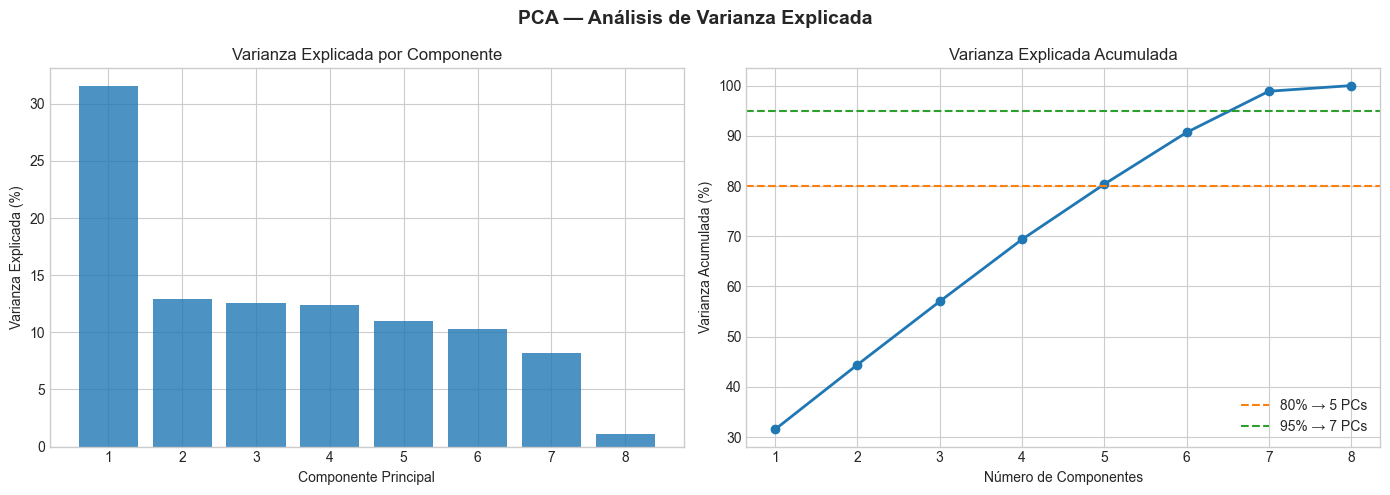


📌 Componentes para explicar 80% de varianza: 5
📌 Componentes para explicar 95% de varianza: 7


In [9]:
# PCA completo para analizar varianza
pca_full = PCA()
pca_full.fit(X_scaled)

var_exp    = pca_full.explained_variance_ratio_
var_cum    = np.cumsum(var_exp)
n_features = len(CLUSTER_FEATURES)

# Número de componentes para 80% y 95%
n_80 = np.argmax(var_cum >= 0.80) + 1
n_95 = np.argmax(var_cum >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Varianza por componente ---
axes[0].bar(range(1, n_features + 1), var_exp * 100, color=PALETTE[0], alpha=0.8)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Varianza Explicada por Componente')
axes[0].set_xticks(range(1, n_features + 1))

# --- Varianza acumulada ---
axes[1].plot(range(1, n_features + 1), var_cum * 100, 'o-', color=PALETTE[0], lw=2)
axes[1].axhline(80, color=PALETTE[1], ls='--', label=f'80% → {n_80} PCs')
axes[1].axhline(95, color=PALETTE[2], ls='--', label=f'95% → {n_95} PCs')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Explicada Acumulada')
axes[1].legend()
axes[1].set_xticks(range(1, n_features + 1))

plt.suptitle('PCA — Análisis de Varianza Explicada', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 Componentes para explicar 80% de varianza: {n_80}')
print(f'📌 Componentes para explicar 95% de varianza: {n_95}')

### 4.2 Proyección en 2D para visualización

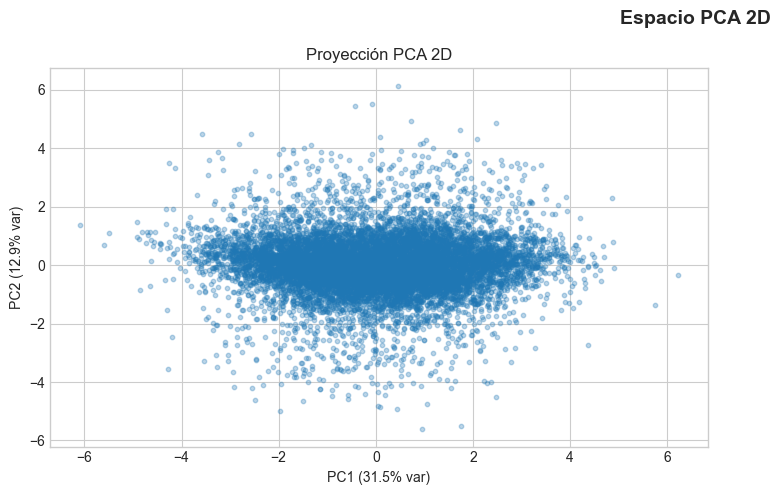

In [10]:
# PCA 2D para visualización
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'], index=X_raw.index)
if y is not None:
    pca_df['blue_win'] = y.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter sin color
axes[0].scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.3, s=10, color=PALETTE[0])
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')
axes[0].set_title('Proyección PCA 2D')

# Scatter coloreado por resultado si existe
if y is not None:
    for label, color, name in zip([1, 0], [PALETTE[0], PALETTE[3]], ['Blue Win', 'Red Win']):
        mask = pca_df['blue_win'] == label
        axes[1].scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                        alpha=0.3, s=10, color=color, label=name)
    axes[1].legend(markerscale=3)
    axes[1].set_title('PCA 2D coloreado por resultado')
else:
    axes[1].set_visible(False)

for ax in axes[:2 if y is not None else 1]:
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')

plt.suptitle('Espacio PCA 2D', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Biplot — Loadings de features

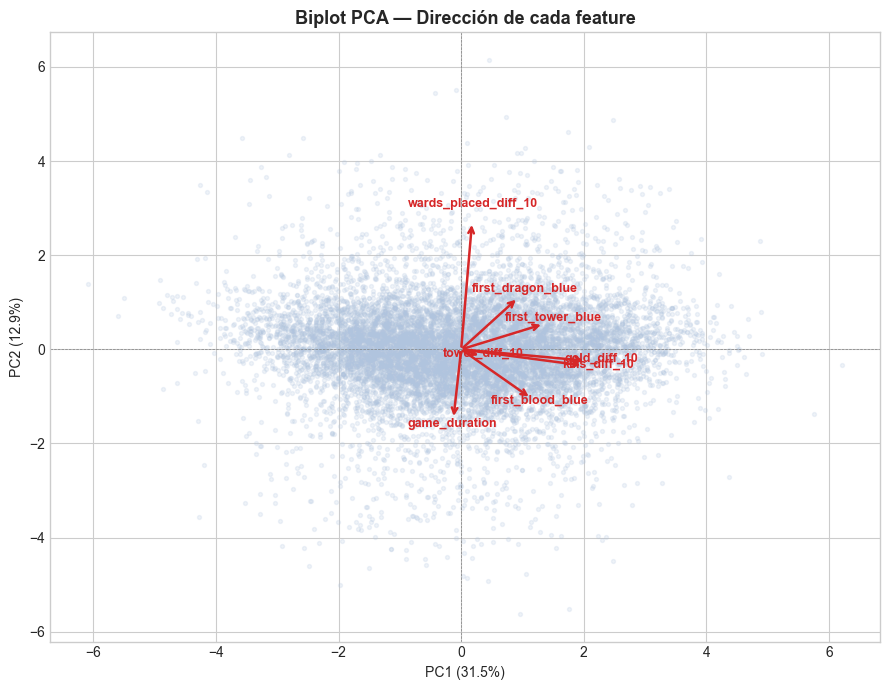


📊 Loadings ordenados por contribución a PC1:


,PC1,PC2
gold_diff_10,0.583,-0.069
kills_diff_10,0.569,-0.098
first_tower_blue,0.384,0.154
first_blood_blue,0.326,-0.296
first_dragon_blue,0.265,0.313
tower_diff_10,0.093,-0.041
wards_placed_diff_10,0.051,0.773
game_duration,-0.036,-0.422


In [11]:
loadings = pca_2d.components_.T  # shape: (n_features, 2)

fig, ax = plt.subplots(figsize=(9, 7))

# Scatter de observaciones
ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.2, s=8, color='lightsteelblue')

# Flechas de loadings
scale = 3.5
for i, feat in enumerate(CLUSTER_FEATURES):
    ax.annotate('', xy=(loadings[i, 0] * scale, loadings[i, 1] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=PALETTE[3], lw=1.8))
    ax.text(loadings[i, 0] * scale * 1.12, loadings[i, 1] * scale * 1.12,
            feat, fontsize=9, ha='center', color=PALETTE[3], fontweight='bold')

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.set_title('Biplot PCA — Dirección de cada feature', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla de loadings
loadings_df = pd.DataFrame(loadings, index=CLUSTER_FEATURES, columns=['PC1', 'PC2'])
loadings_df['|PC1|'] = loadings_df['PC1'].abs()
print('\n📊 Loadings ordenados por contribución a PC1:')
loadings_df.sort_values('|PC1|', ascending=False).drop(columns='|PC1|').round(3)

## 5. Preparar espacio PCA para clustering

In [12]:
# Usamos los componentes que explican ~80% de varianza para el clustering
N_COMPONENTS = n_80
print(f'🔧 Usando {N_COMPONENTS} componentes PCA ({var_cum[N_COMPONENTS-1]*100:.1f}% varianza)')

pca_nd = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca_nd.fit_transform(X_scaled)

print(f'📐 Forma del espacio PCA: {X_pca.shape}')

🔧 Usando 5 componentes PCA (80.4% varianza)
📐 Forma del espacio PCA: (11415, 5)


## 6. Algoritmo 1 — K-Means

### 6.1 Elbow Method + Silhouette para elegir K

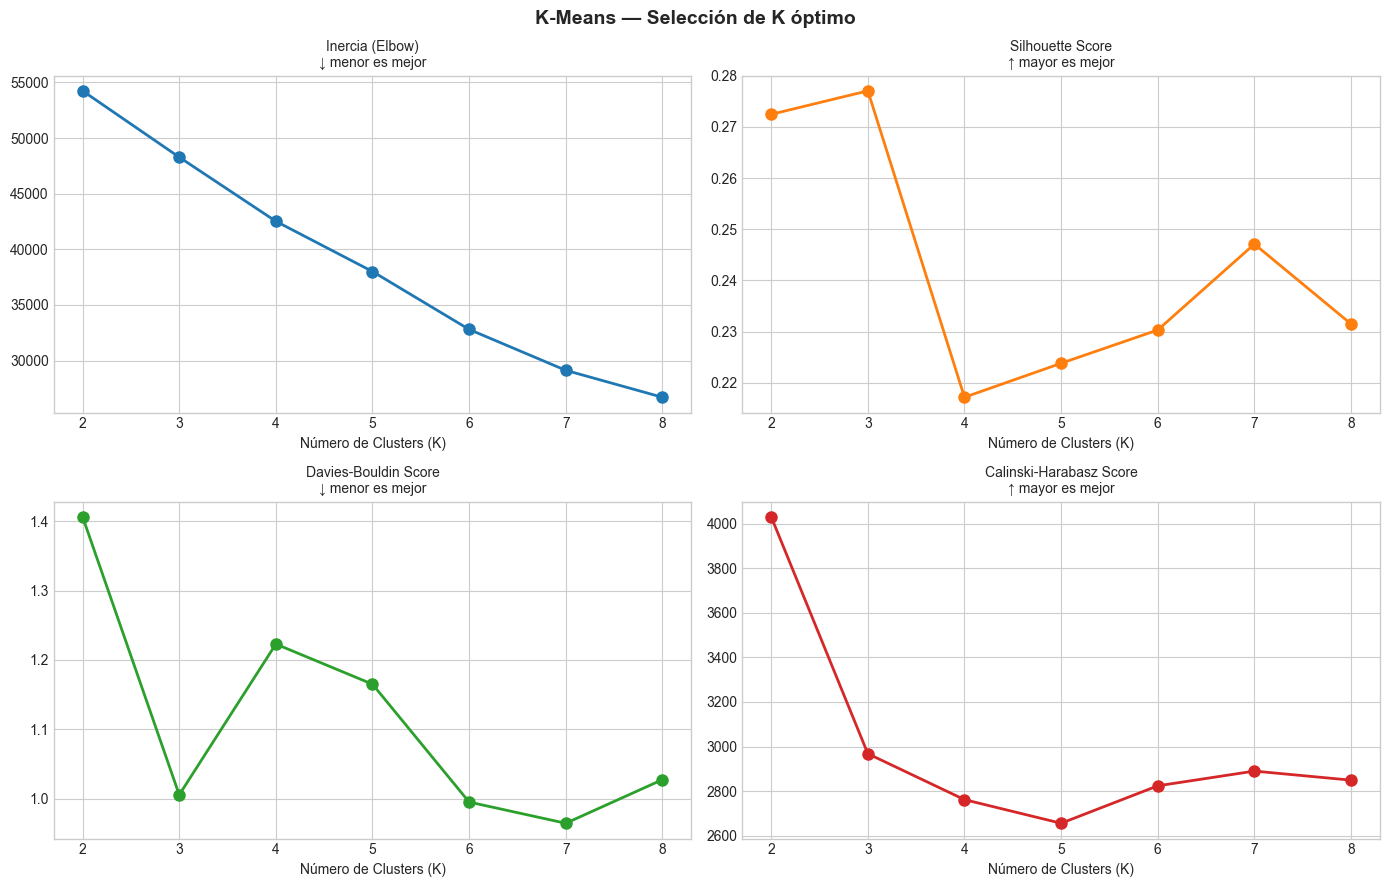

📊 Métricas por K:


,K,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,54238.1370,0.2724,1.4061,4029.9459
1,3,48277.8079,0.2770,1.0059,2967.9955
2,4,42516.5295,0.2172,1.2229,2762.0273
3,5,38002.8842,0.2238,1.1651,2656.1657
4,6,32798.1753,0.2303,0.9955,2824.0421
5,7,29122.9181,0.2471,0.9649,2890.0839
6,8,26701.2937,0.2315,1.0277,2849.3920


In [13]:
K_RANGE = range(2, 9)
inertias, silhouettes, db_scores, ch_scores = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics = [
    (inertias,    'Inercia (Elbow)',              '↓ menor es mejor', PALETTE[0]),
    (silhouettes, 'Silhouette Score',             '↑ mayor es mejor', PALETTE[1]),
    (db_scores,   'Davies-Bouldin Score',         '↓ menor es mejor', PALETTE[2]),
    (ch_scores,   'Calinski-Harabasz Score',      '↑ mayor es mejor', PALETTE[3]),
]

for ax, (vals, title, note, color) in zip(axes.flat, metrics):
    ax.plot(list(K_RANGE), vals, 'o-', color=color, lw=2, ms=8)
    ax.set_xlabel('Número de Clusters (K)')
    ax.set_title(f'{title}\n{note}', fontsize=10)
    ax.set_xticks(list(K_RANGE))

plt.suptitle('K-Means — Selección de K óptimo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
metrics_df = pd.DataFrame({
    'K': list(K_RANGE),
    'Inertia': inertias,
    'Silhouette': silhouettes,
    'Davies-Bouldin': db_scores,
    'Calinski-Harabasz': ch_scores
})
metrics_df = metrics_df.round(4)
print('📊 Métricas por K:')
metrics_df

In [14]:
# ✏️ Elegir K basado en las métricas anteriores
K_OPTIMAL = 4  # Ajusta según las gráficas

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, labels_kmeans)
db  = davies_bouldin_score(X_pca, labels_kmeans)
ch  = calinski_harabasz_score(X_pca, labels_kmeans)

print(f'✅ K-Means con K={K_OPTIMAL}:')
print(f'   Silhouette:          {sil:.4f}  (rango -1 a 1, >0.3 aceptable)')
print(f'   Davies-Bouldin:      {db:.4f}   (menor es mejor)')
print(f'   Calinski-Harabasz:   {ch:.1f}  (mayor es mejor)')
print(f'\n📊 Distribución de clusters:')
print(pd.Series(labels_kmeans).value_counts().sort_index())

✅ K-Means con K=4:
   Silhouette:          0.2172  (rango -1 a 1, >0.3 aceptable)
   Davies-Bouldin:      1.2229   (menor es mejor)
   Calinski-Harabasz:   2762.0  (mayor es mejor)

📊 Distribución de clusters:
0    3642
1    3605
2    4141
3      27
Name: count, dtype: int64


### 6.2 Visualización K-Means en PCA 2D

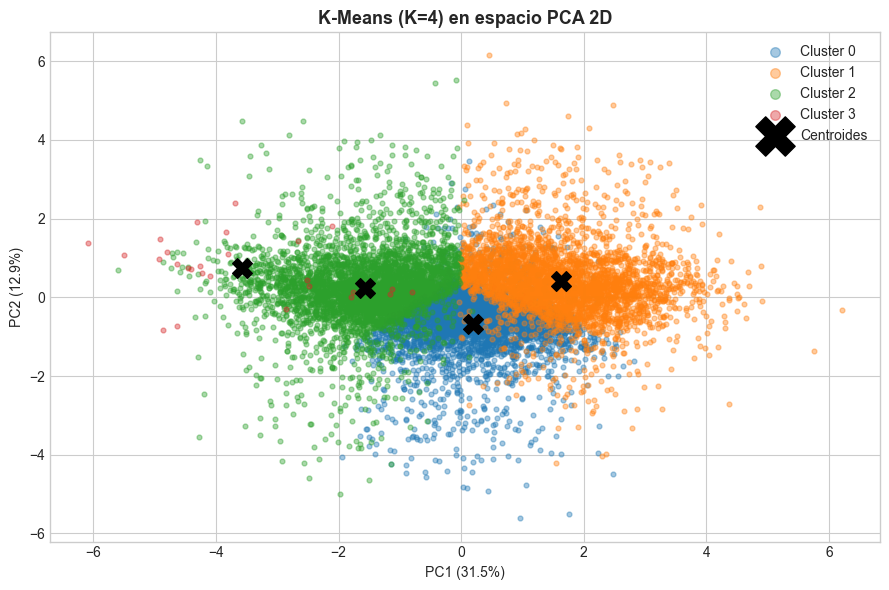

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))

for k in range(K_OPTIMAL):
    mask = labels_kmeans == k
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               alpha=0.4, s=12, color=PALETTE[k % len(PALETTE)], label=f'Cluster {k}')

# Centroides proyectados en 2D
centroids_2d = pca_2d.transform(scaler.transform(
    scaler.inverse_transform(pca_nd.inverse_transform(kmeans.cluster_centers_))
))
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           marker='X', s=200, c='black', zorder=5, label='Centroides')

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.set_title(f'K-Means (K={K_OPTIMAL}) en espacio PCA 2D', fontsize=13, fontweight='bold')
ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig('kmeans_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Algoritmo 2 — Clustering Jerárquico

### 7.1 Dendrograma

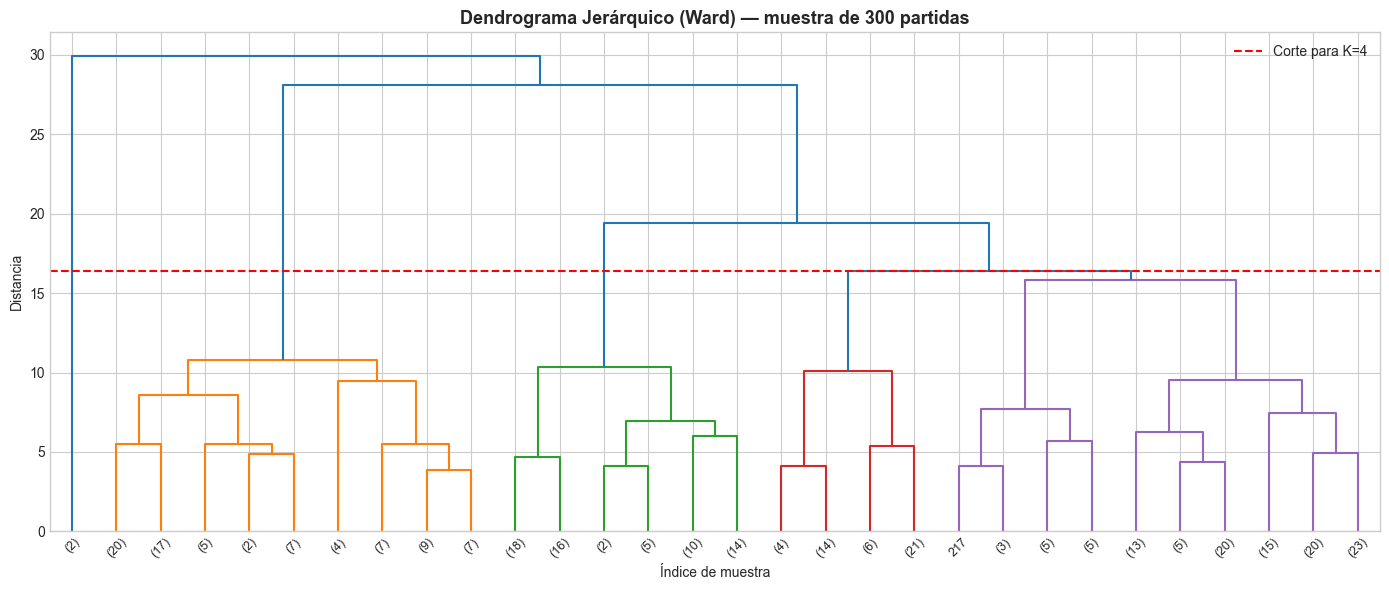

In [16]:
# Muestra aleatoria para el dendrograma (evitar sobrecarga visual)
SAMPLE_N = min(300, len(X_pca))
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), SAMPLE_N, replace=False)
X_sample   = X_pca[sample_idx]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=9,
           color_threshold=Z[-K_OPTIMAL, 2])

# Línea de corte para K clusters
threshold = Z[-(K_OPTIMAL), 2]
ax.axhline(threshold, color='red', ls='--', lw=1.5, label=f'Corte para K={K_OPTIMAL}')
ax.set_title(f'Dendrograma Jerárquico (Ward) — muestra de {SAMPLE_N} partidas',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Índice de muestra')
ax.set_ylabel('Distancia')
ax.legend()

plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Aplicar clustering jerárquico con el mismo K
hier = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
labels_hier = hier.fit_predict(X_pca)

sil_h = silhouette_score(X_pca, labels_hier)
db_h  = davies_bouldin_score(X_pca, labels_hier)
ch_h  = calinski_harabasz_score(X_pca, labels_hier)

print(f'✅ Clustering Jerárquico (Ward, K={K_OPTIMAL}):')
print(f'   Silhouette:          {sil_h:.4f}')
print(f'   Davies-Bouldin:      {db_h:.4f}')
print(f'   Calinski-Harabasz:   {ch_h:.1f}')

✅ Clustering Jerárquico (Ward, K=4):
   Silhouette:          0.1990
   Davies-Bouldin:      1.4805
   Calinski-Harabasz:   2053.2


## 8. Algoritmo 3 — DBSCAN

### 8.1 Selección de epsilon (k-distance plot)

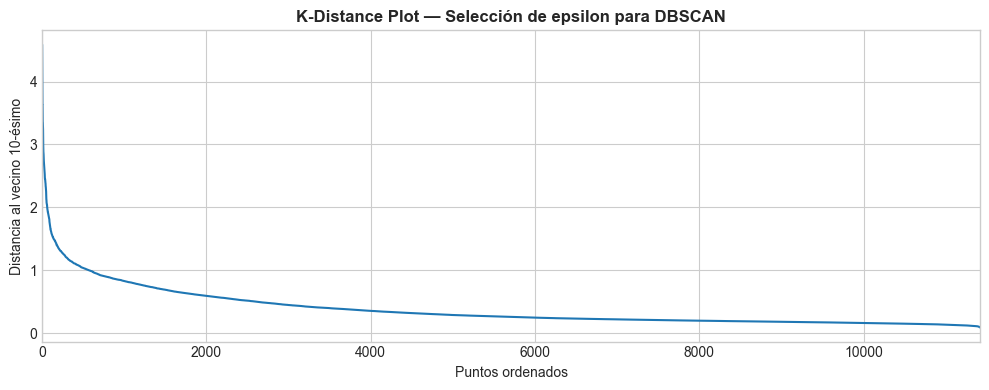

💡 Busca el "codo" en la curva para elegir epsilon.
   Percentil 90 de distancias: 0.157
   Percentil 95 de distancias: 0.142


In [18]:
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 10  # Regla práctica: 2 × n_features
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_distances   = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, color=PALETTE[0], lw=1.5)
ax.set_xlabel('Puntos ordenados')
ax.set_ylabel(f'Distancia al vecino {MIN_SAMPLES}-ésimo')
ax.set_title('K-Distance Plot — Selección de epsilon para DBSCAN',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, len(k_distances))

plt.tight_layout()
plt.savefig('dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Busca el "codo" en la curva para elegir epsilon.')
print(f'   Percentil 90 de distancias: {np.percentile(k_distances, 10):.3f}')
print(f'   Percentil 95 de distancias: {np.percentile(k_distances, 5):.3f}')

In [19]:
# ✏️ Ajusta EPS según el k-distance plot
EPS = 1.5  # Ajustar según la gráfica anterior

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise       = (labels_dbscan == -1).sum()
n_noise_pct   = n_noise / len(labels_dbscan) * 100

print(f'✅ DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}):')
print(f'   Clusters encontrados: {n_clusters_db}')
print(f'   Puntos ruido:         {n_noise} ({n_noise_pct:.1f}%)')

if n_clusters_db > 1:
    mask_valid = labels_dbscan != -1
    sil_d = silhouette_score(X_pca[mask_valid], labels_dbscan[mask_valid])
    db_d  = davies_bouldin_score(X_pca[mask_valid], labels_dbscan[mask_valid])
    print(f'   Silhouette (sin ruido): {sil_d:.4f}')
    print(f'   Davies-Bouldin:         {db_d:.4f}')
else:
    print('   ⚠️  Solo 1 cluster — ajusta EPS')

✅ DBSCAN (eps=1.5, min_samples=10):
   Clusters encontrados: 2
   Puntos ruido:         58 (0.5%)
   Silhouette (sin ruido): 0.8042
   Davies-Bouldin:         0.2001


## 9. Comparativa de los 3 algoritmos

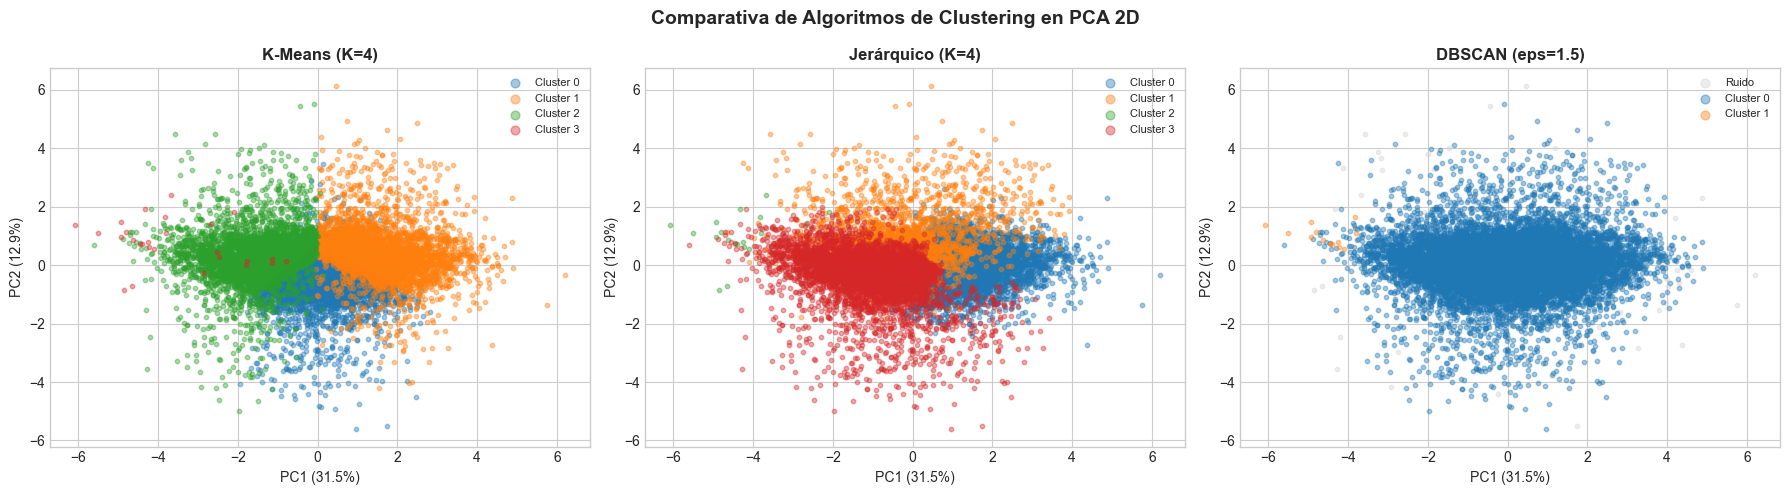

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

algo_configs = [
    (labels_kmeans,  f'K-Means (K={K_OPTIMAL})'),
    (labels_hier,    f'Jerárquico (K={K_OPTIMAL})'),
    (labels_dbscan,  f'DBSCAN (eps={EPS})'),
]

for ax, (labels, title) in zip(axes, algo_configs):
    unique_labels = sorted(set(labels))
    for k in unique_labels:
        mask = labels == k
        label_name = f'Ruido' if k == -1 else f'Cluster {k}'
        color = 'lightgray' if k == -1 else PALETTE[k % len(PALETTE)]
        ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                   alpha=0.4, s=10, color=color, label=label_name)
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(markerscale=2, fontsize=8)

plt.suptitle('Comparativa de Algoritmos de Clustering en PCA 2D',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Tabla resumen de métricas
sil_d_val = sil_d if n_clusters_db > 1 else float('nan')
db_d_val  = db_d  if n_clusters_db > 1 else float('nan')

comparison_df = pd.DataFrame({
    'Algoritmo': [f'K-Means (K={K_OPTIMAL})', f'Jerárquico (K={K_OPTIMAL})', f'DBSCAN (eps={EPS})'],
    'Silhouette ↑':        [sil,     sil_h,   sil_d_val],
    'Davies-Bouldin ↓':    [db,      db_h,    db_d_val],
    'Calinski-Harabasz ↑': [ch,      ch_h,    float('nan')],
    'N Clusters':          [K_OPTIMAL, K_OPTIMAL, n_clusters_db],
    'Ruido (%)':           [0, 0, n_noise_pct],
})

print('📊 Comparativa de algoritmos:')
comparison_df.round(4)

📊 Comparativa de algoritmos:


,Algoritmo,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,N Clusters,Ruido (%)
0,K-Means (K=4),0.2172,1.2229,2762.0273,4,0.0000
1,Jerárquico (K=4),0.1990,1.4805,2053.2147,4,0.0000
2,DBSCAN (eps=1.5),0.8042,0.2001,NaN,2,0.5081


## 10. Interpretación de clusters — Arquetipos de partida

Usamos el mejor algoritmo según las métricas (ajusta `BEST_LABELS` si corresponde).

In [22]:
# ✏️ Selecciona el mejor algoritmo según las métricas anteriores
BEST_LABELS = labels_kmeans  # Cambiar a labels_hier o labels_dbscan si aplica
BEST_NAME   = f'K-Means (K={K_OPTIMAL})'

# Agregar labels al dataframe original
df_cluster = X_raw.copy()
df_cluster['cluster'] = BEST_LABELS
if y is not None:
    df_cluster['blue_win'] = y

# Estadísticas por cluster
cluster_stats = df_cluster.groupby('cluster')[CLUSTER_FEATURES].mean().round(3)
print(f'📊 Media de features por cluster ({BEST_NAME}):')
cluster_stats

📊 Media de features por cluster (K-Means (K=4)):


,kills_diff_10,gold_diff_10,tower_diff_10,wards_placed_diff_10,first_blood_blue,first_tower_blue,first_dragon_blue,game_duration
cluster,,,,,,,,
0,0.810,314.694,0.001,-8.577,0.769,0.465,0.210,36.137
1,3.277,1571.958,0.005,8.536,0.664,0.848,0.876,29.814
2,-3.170,-1551.740,0.000,-0.207,0.144,0.194,0.336,31.491
3,-3.741,-2973.593,-1.000,-21.296,0.259,0.000,0.370,28.231


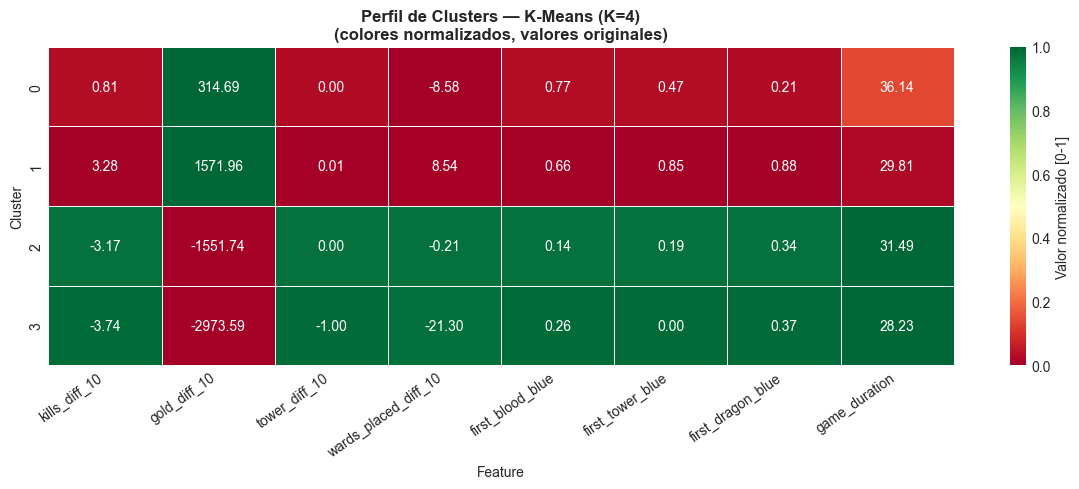

In [23]:
# Heatmap de perfiles de cluster
from sklearn.preprocessing import MinMaxScaler

cluster_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_stats.T).T,
    index=cluster_stats.index,
    columns=cluster_stats.columns
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cluster_scaled, annot=cluster_stats, fmt='.2f',
            cmap='RdYlGn', center=0.5, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Valor normalizado [0-1]'})
ax.set_title(f'Perfil de Clusters — {BEST_NAME}\n(colores normalizados, valores originales)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.xticks(rotation=35, ha='right')

plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ✏️ Asigna nombres a los arquetipos según lo que observas en el heatmap
ARCHETYPE_NAMES = {
    0: '🔴 Dominancia Red (kills+gold)',
    1: '🔵 Dominancia Blue (macro)',
    2: '⚔️  Partida Equilibrada',
    3: '🏰 Victoria por Objetivos',
}

df_cluster['archetype'] = df_cluster['cluster'].map(ARCHETYPE_NAMES)

print('📊 Distribución de arquetipos:')
print(df_cluster['archetype'].value_counts())

📊 Distribución de arquetipos:
archetype
⚔️  Partida Equilibrada          4141
🔴 Dominancia Red (kills+gold)    3642
🔵 Dominancia Blue (macro)        3605
🏰 Victoria por Objetivos           27
Name: count, dtype: int64


## 11. Conexión con Winrate — Link al modelo predictivo

In [25]:
if y is not None:
    winrate_by_cluster = (
        df_cluster.groupby('cluster')['blue_win']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'blue_winrate', 'count': 'n_partidas'})
    )
    winrate_by_cluster['blue_winrate_pct'] = (winrate_by_cluster['blue_winrate'] * 100).round(1)
    winrate_by_cluster['archetype'] = winrate_by_cluster.index.map(ARCHETYPE_NAMES)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(range(K_OPTIMAL),
                  winrate_by_cluster['blue_winrate_pct'],
                  color=[PALETTE[i] for i in range(K_OPTIMAL)],
                  edgecolor='white', linewidth=1.2)

    ax.axhline(50, color='gray', ls='--', lw=1.5, label='50% (baseline)')
    for bar, val in zip(bars, winrate_by_cluster['blue_winrate_pct']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

    ax.set_xticks(range(K_OPTIMAL))
    ax.set_xticklabels([ARCHETYPE_NAMES.get(i, f'Cluster {i}') for i in range(K_OPTIMAL)],
                       rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Blue Winrate (%)')
    ax.set_ylim(0, 100)
    ax.set_title('Winrate de Blue por Arquetipo de Partida', fontsize=13, fontweight='bold')
    ax.legend()

    plt.tight_layout()
    plt.savefig('cluster_winrate.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n📊 Resumen por arquetipo:')
    print(winrate_by_cluster[['archetype', 'n_partidas', 'blue_winrate_pct']])
else:
    print('⚠️  No se encontró la columna target para calcular winrate')

⚠️  No se encontró la columna target para calcular winrate


## 12. Resumen ejecutivo

In [26]:
print('=' * 60)
print('📋 RESUMEN EJECUTIVO — Clustering LoL')
print('=' * 60)
print(f'\n🔢 Dataset: {X_raw.shape[0]:,} partidas | {len(CLUSTER_FEATURES)} features')
print(f'\n📐 PCA:')
print(f'   Componentes usados:  {N_COMPONENTS}')
print(f'   Varianza explicada:  {var_cum[N_COMPONENTS-1]*100:.1f}%')
print(f'\n🏆 Mejor algoritmo: {BEST_NAME}')
print(f'   Silhouette:  {silhouette_score(X_pca, BEST_LABELS):.4f}')
print(f'\n🎮 Arquetipos identificados:')
for k, name in ARCHETYPE_NAMES.items():
    n = (BEST_LABELS == k).sum()
    pct = n / len(BEST_LABELS) * 100
    print(f'   {name}: {n} partidas ({pct:.1f}%)')
print('=' * 60)

📋 RESUMEN EJECUTIVO — Clustering LoL

🔢 Dataset: 11,415 partidas | 8 features

📐 PCA:
   Componentes usados:  5
   Varianza explicada:  80.4%

🏆 Mejor algoritmo: K-Means (K=4)
   Silhouette:  0.2172

🎮 Arquetipos identificados:
   🔴 Dominancia Red (kills+gold): 3642 partidas (31.9%)
   🔵 Dominancia Blue (macro): 3605 partidas (31.6%)
   ⚔️  Partida Equilibrada: 4141 partidas (36.3%)
   🏰 Victoria por Objetivos: 27 partidas (0.2%)
